# Training Denoiser: Locked Parameters

**Status:** Ready to train  
**Configuration:** Measurement-grounded from notebooks 01-10  
**Date:** 2026-04-25

## Features
- ✅ Logging to file (`logs/train.log`)
- ✅ Checkpoint saving every 10 epochs
- ✅ Resumable from checkpoint
- ✅ Mixed precision + gradient checkpointing
- ✅ N2V3D masking

## Quick Test
Set `TEST_MODE = True` below to run 5 epochs (~1-2 hours)

In [1]:
import sys
from pathlib import Path

# CRITICAL: Set path to src BEFORE importing local modules
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
import logging
import json
from datetime import datetime

# Local imports (now that src is in path)
from config import *
from model import UNet3D
from loss import PGNLLLoss
from dataset import PatchDataset, N2V3DMask
from training_utils import EarlyStopping
from cidc import load_stack

print("✓ Imports OK")
print(f"✓ sys.path[0] = {sys.path[0]}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {device}")

✓ Imports OK
✓ sys.path[0] = /teamspace/studios/this_studio/src
✓ Device: cuda


## Settings

In [2]:
# ============================================================================
# SETTINGS (All configuration in one place)
# ============================================================================

TEST_MODE = True
RESUME_FROM_CHECKPOINT = None

# Training parameters
if TEST_MODE:
    EPOCHS = 1              # Quick test: 1 epoch
    BATCH_SIZE = 1        # Quick test: larger batches
    print("⚡ QUICK TEST MODE: 1 epoch, batch_size=16, ~2 min")
else:
    EPOCHS = 100            # Full training
    BATCH_SIZE = 4          # Full training: fits in 16GB
    print("🚀 FULL TRAINING: 100 epochs, batch_size=4")

# Dataset parameters
STACK_NAMES = ['A1', 'B1'] if TEST_MODE else ['A1', 'B1', 'C2', 'D2']
N_PATCHES_PER_STACK = 50 if TEST_MODE else 250
NUM_WORKERS = 0 if TEST_MODE else 4
PIN_MEMORY = False if TEST_MODE else True

# Setup directories
LOG_DIR = Path.cwd() / "logs"
LOG_DIR.mkdir(exist_ok=True)

CHECKPOINT_DIR = Path.cwd() / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)

DATA_DIR = Path.cwd().parent / "data"

# Log file
log_file = LOG_DIR / f"train_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

# Print settings
print(f"\n{'='*80}")
print("SETTINGS")
print(f"{'='*80}")
print(f"Epochs:              {EPOCHS}")
print(f"Batch size:          {BATCH_SIZE}")
print(f"Stacks:              {STACK_NAMES}")
print(f"Patches per stack:   {N_PATCHES_PER_STACK}")
print(f"Num workers:         {NUM_WORKERS}")
print(f"Total patches:       {len(STACK_NAMES) * N_PATCHES_PER_STACK}")
print(f"Log directory:       {LOG_DIR}")
print(f"Data directory:      {DATA_DIR}")
print(f"{'='*80}\n")

⚡ QUICK TEST MODE: 1 epoch, batch_size=16, ~2 min

SETTINGS
Epochs:              1
Batch size:          1
Stacks:              ['A1', 'B1']
Patches per stack:   50
Num workers:         0
Total patches:       100
Log directory:       /teamspace/studios/this_studio/training/logs
Data directory:      /teamspace/studios/this_studio/data



## Logging Setup

In [3]:
# Setup logging to both file and console
logger = logging.getLogger('training')
logger.setLevel(logging.INFO)

# File handler
fh = logging.FileHandler(log_file)
fh.setLevel(logging.INFO)

# Console handler
ch = logging.StreamHandler()
ch.setLevel(logging.INFO)

# Formatter
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
fh.setFormatter(formatter)
ch.setFormatter(formatter)

logger.addHandler(fh)
logger.addHandler(ch)

logger.info("\n" + "="*80)
logger.info("TRAINING DENOISER (LOCKED PARAMETERS)")
logger.info("="*80)
logger.info(f"Log file: {log_file}")
logger.info(f"Device: {device}")

2026-04-25 09:08:59,836 - INFO - 
2026-04-25 09:08:59,836 - INFO - TRAINING DENOISER (LOCKED PARAMETERS)
2026-04-25 09:08:59,837 - INFO - ================================================================================
2026-04-25 09:08:59,837 - INFO - Log file: /teamspace/studios/this_studio/training/logs/train_20260425_090859.log
2026-04-25 09:08:59,838 - INFO - Device: cuda


## Configuration Summary

In [4]:
logger.info("\n" + "="*80)
logger.info("CONFIGURATION")
logger.info("="*80)

logger.info("\nNoise Parameters:")
for stack, params in NOISE_PARAMS.items():
    logger.info(f"  {stack}: g={params['g']:.1f}, σ_r²={params['sigma_r_sq']:.0f}")

logger.info(f"\nAugmentation:")
logger.info(f"  Gain range: [{G_AUG_MIN}, {G_AUG_MAX}]")
logger.info(f"  Read noise: σ_r²={SIGMA_R_SQ_AUG}")

logger.info(f"\nArchitecture:")
logger.info(f"  Patch size: {PATCH_SIZE}")
logger.info(f"  Input channels: {IN_CHANNELS}")
logger.info(f"  Channel depths: {CHANNELS}")

logger.info(f"\nTraining:")
logger.info(f"  Batch size: {BATCH_SIZE}")
logger.info(f"  Epochs: {EPOCHS}")
logger.info(f"  LR: {LR}")
logger.info(f"  Grad clip: {GRAD_CLIP}")
logger.info(f"  Mask ratio: {MASK_RATIO*100:.1f}%")

logger.info(f"\nBaseline (no denoising):")
logger.info(f"  F1: {LOCKED_DECISIONS['baseline_F1']:.2f} dB")
logger.info(f"  F2: {LOCKED_DECISIONS['baseline_F2']:.2f} dB")
logger.info(f"  F3: {LOCKED_DECISIONS['baseline_F3']:.2f} dB")

2026-04-25 09:08:59,846 - INFO - 
2026-04-25 09:08:59,847 - INFO - CONFIGURATION
2026-04-25 09:08:59,848 - INFO - ================================================================================
2026-04-25 09:08:59,848 - INFO - 
Noise Parameters:
2026-04-25 09:08:59,849 - INFO -   A1: g=27.6, σ_r²=2490
2026-04-25 09:08:59,850 - INFO -   B1: g=27.7, σ_r²=2490
2026-04-25 09:08:59,851 - INFO -   C2: g=254.9, σ_r²=2700
2026-04-25 09:08:59,851 - INFO -   D2: g=258.9, σ_r²=2700
2026-04-25 09:08:59,852 - INFO - 
Augmentation:
2026-04-25 09:08:59,852 - INFO -   Gain range: [15, 1500]
2026-04-25 09:08:59,853 - INFO -   Read noise: σ_r²=2700
2026-04-25 09:08:59,854 - INFO - 
Architecture:
2026-04-25 09:08:59,854 - INFO -   Patch size: (128, 128, 128)
2026-04-25 09:08:59,855 - INFO -   Input channels: 2
2026-04-25 09:08:59,856 - INFO -   Channel depths: [32, 64, 128]
2026-04-25 09:08:59,857 - INFO - 
Training:
2026-04-25 09:08:59,857 - INFO -   Batch size: 1
2026-04-25 09:08:59,858 - INFO -   Epo

## Data Loading

In [5]:
logger.info("\nLoading dataset...")
dataset = PatchDataset(
    stack_names=STACK_NAMES,
    noise_params=NOISE_PARAMS,
    patch_size=PATCH_SIZE,
    g_aug_min=G_AUG_MIN,
    g_aug_max=G_AUG_MAX,
    sigma_r_sq_aug=SIGMA_R_SQ_AUG,
    data_dir=DATA_DIR,
    n_patches_per_stack=N_PATCHES_PER_STACK,
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

logger.info(f"Dataset: {len(dataset)} patches ({len(dataset)//BATCH_SIZE} batches)")

# Test batch
batch = next(iter(loader))
logger.info(f"Batch shapes: x={batch['x'].shape}, y={batch['y'].shape}")

2026-04-25 09:08:59,869 - INFO - 
Loading dataset...


Loaded A1: (1500, 490, 490)


2026-04-25 09:09:00,917 - INFO - Dataset: 100 patches (100 batches)


Loaded B1: (1500, 490, 490)


2026-04-25 09:09:01,259 - INFO - Batch shapes: x=torch.Size([1, 2, 128, 128, 128]), y=torch.Size([1, 1, 128, 128, 128])


## Model Setup

In [6]:
logger.info("\nBuilding model...")
model = UNet3D(
    in_channels=IN_CHANNELS,
    out_channels=OUT_CHANNELS,
    channels=CHANNELS,
)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
logger.info(f"Model: {n_params:,} parameters")

# Optimizer
optimizer = Adam(model.parameters(), lr=LR)
scaler = GradScaler()
logger.info(f"Optimizer: Adam (lr={LR})")
logger.info(f"Mixed precision: enabled")

# Loss
loss_fn = PGNLLLoss()
logger.info(f"Loss: Poisson-Gaussian NLL")

# Masking
mask_fn = N2V3DMask(mask_ratio=MASK_RATIO)
logger.info(f"Masking: N2V3D ({MASK_RATIO*100:.1f}%)")

2026-04-25 09:09:01,264 - INFO - 
Building model...
2026-04-25 09:09:01,389 - INFO - Model: 2,243,009 parameters
/tmp/ipykernel_147625/2129511304.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
2026-04-25 09:09:02,209 - INFO - Optimizer: Adam (lr=0.0001)
2026-04-25 09:09:02,209 - INFO - Mixed precision: enabled
2026-04-25 09:09:02,210 - INFO - Loss: Poisson-Gaussian NLL
2026-04-25 09:09:02,211 - INFO - Masking: N2V3D (0.5%)


## Resume from Checkpoint (Optional)

In [2]:
start_epoch = 0

if RESUME_FROM_CHECKPOINT:
    if RESUME_FROM_CHECKPOINT == 'latest':
        # Find latest checkpoint
        ckpts = sorted(CHECKPOINT_DIR.glob('model_epoch_*.pt'))
        if ckpts:
            ckpt_path = ckpts[-1]
        else:
            logger.warning("No checkpoints found, starting from scratch")
            ckpt_path = None
    else:
        ckpt_path = CHECKPOINT_DIR / RESUME_FROM_CHECKPOINT

    if ckpt_path and ckpt_path.exists():
        checkpoint = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(checkpoint['model'])
        optimizer.load_state_dict(checkpoint['optimizer'])
        start_epoch = checkpoint['epoch']
        logger.info(f"\n✓ Resumed from {ckpt_path} (epoch {start_epoch})")
    else:
        logger.warning(f"Checkpoint not found: {ckpt_path}, starting from scratch")

NameError: name 'RESUME_FROM_CHECKPOINT' is not defined

## Training Loop

In [7]:
def train_epoch(epoch):
    model.train()
    total_loss = 0

    for batch_idx, batch in enumerate(loader):
        x = batch['x'].to(device, dtype=torch.float32)
        y = batch['y'].to(device, dtype=torch.float32)
        g = batch['g']
        sigma_r_sq = batch['sigma_r_sq']

        # N2V3D mask
        mask = mask_fn(y.shape[2:]).to(device)
        mask = mask.unsqueeze(0).expand(y.shape[0], -1, -1, -1)

        optimizer.zero_grad()

        # Forward (no autocast - use full float32)
        y_pred = model(x)
        loss = loss_fn(y_pred, y, g, sigma_r_sq, mask)

        # Backward with gradient clipping
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 10 == 0:
            logger.info(f"Epoch {epoch+1} Batch {batch_idx+1}: loss={loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    return avg_loss

logger.info("✓ Training function defined (float32, no mixed precision)")

2026-04-25 09:09:06,613 - INFO - ✓ Training function defined (float32, no mixed precision)


In [8]:
def validate(model, device, patch_size, data_dir):
    """Compute stSNR on validation stacks (F1, F2, F3)."""
    from evaluate import denoise_stack, spatio_temporal_snr
    
    model.eval()
    clean_path = data_dir / "val" / "F0.tif"
    clean = np.asarray(load_stack(clean_path), dtype=np.float32)

    val_stacks = ['F1', 'F2', 'F3']
    results = {}

    with torch.no_grad():
        for stack_name in val_stacks:
            stack_path = data_dir / "val" / f"{stack_name}.tif"
            noisy = np.asarray(load_stack(stack_path), dtype=np.float32)
            denoised = denoise_stack(model, noisy, device, patch_size=patch_size[0])
            metrics = spatio_temporal_snr(clean, denoised)
            results[stack_name] = metrics['stSNR']

    model.train()  # Return to training mode
    combined = 0.5 * results['F1'] + 0.5 * (results['F2'] + results['F3']) / 2
    return combined, results

logger.info("✓ Validation function defined")
start_epoch = 0  # Initialize if not already set

logger.info("\n" + "="*80)
logger.info(f"STARTING TRAINING ({datetime.now().strftime('%Y-%m-%d %H:%M:%S')})")
logger.info("="*80 + "\n")

losses = []
start_time = datetime.now()

try:
    for epoch in range(start_epoch, EPOCHS):
        avg_loss = train_epoch(epoch)
        losses.append(avg_loss)
        logger.info(f">>> Epoch {epoch+1}/{EPOCHS}: avg_loss={avg_loss:.4f}")

        # Checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0 or (epoch + 1) == EPOCHS:
            ckpt_path = CHECKPOINT_DIR / f"model_epoch_{epoch+1:03d}.pt"
            torch.save({
                'epoch': epoch + 1,
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'loss': avg_loss,
            }, ckpt_path)
            logger.info(f"✓ Checkpoint saved: {ckpt_path}\n")

except KeyboardInterrupt:
    logger.warning("\n⚠ Training interrupted by user")
    logger.info(f"Can resume with: RESUME_FROM_CHECKPOINT = 'latest'")
except Exception as e:
    logger.error(f"\n❌ Training failed: {e}", exc_info=True)
    raise

elapsed = datetime.now() - start_time
logger.info("\n" + "="*80)
logger.info("TRAINING COMPLETE")
logger.info("="*80)
logger.info(f"Epochs completed: {len(losses)}")
logger.info(f"Final loss: {losses[-1]:.4f}")
logger.info(f"Time elapsed: {elapsed}")
logger.info(f"Checkpoints: {CHECKPOINT_DIR}")

2026-04-25 09:09:13,200 - INFO - ✓ Validation function defined
2026-04-25 09:09:13,201 - INFO - 
2026-04-25 09:09:13,202 - INFO - STARTING TRAINING (2026-04-25 09:09:13)
2026-04-25 09:09:13,203 - INFO - ================================================================================

2026-04-25 09:09:27,938 - INFO - Epoch 1 Batch 10: loss=36.1432
2026-04-25 09:09:42,158 - INFO - Epoch 1 Batch 20: loss=5.6147
2026-04-25 09:09:56,273 - INFO - Epoch 1 Batch 30: loss=6.6993
2026-04-25 09:10:10,523 - INFO - Epoch 1 Batch 40: loss=5.1432
2026-04-25 09:10:24,777 - INFO - Epoch 1 Batch 50: loss=4.7238
2026-04-25 09:10:39,117 - INFO - Epoch 1 Batch 60: loss=11.2382
2026-04-25 09:10:53,492 - INFO - Epoch 1 Batch 70: loss=6.4327
2026-04-25 09:11:07,845 - INFO - Epoch 1 Batch 80: loss=9.1643
2026-04-25 09:11:22,135 - INFO - Epoch 1 Batch 90: loss=5.2858
2026-04-25 09:11:36,430 - INFO - Epoch 1 Batch 100: loss=6.7624
2026-04-25 09:11:36,432 - INFO - >>> Epoch 1/1: avg_loss=12.1739
2026-04-25 09:11:

## Save Final Model & Metadata

In [9]:
# Save final model
final_path = CHECKPOINT_DIR / "model_final.pt"
torch.save({
    'epoch': EPOCHS,
    'model': model.state_dict(),
    'optimizer': optimizer.state_dict(),
    'loss': losses[-1] if losses else None,
}, final_path)
logger.info(f"\n✓ Final model saved: {final_path}")

# Save metadata
metadata = {
    'epochs': len(losses),
    'final_loss': float(losses[-1]) if losses else None,
    'patch_size': PATCH_SIZE,
    'batch_size': BATCH_SIZE,
    'lr': LR,
    'n_parameters': int(n_params),
    'device': str(device),
    'elapsed_seconds': elapsed.total_seconds(),
    'timestamp': datetime.now().isoformat(),
    'test_mode': TEST_MODE,
}
with open(CHECKPOINT_DIR / "metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)
logger.info(f"✓ Metadata saved: {CHECKPOINT_DIR / 'metadata.json'}")

logger.info(f"\n✓ Log file: {log_file}")
logger.info("\nTo resume training: RESUME_FROM_CHECKPOINT = 'latest'")

2026-04-25 09:11:43,828 - INFO - 
✓ Final model saved: /teamspace/studios/this_studio/training/checkpoints/model_final.pt
2026-04-25 09:11:43,830 - INFO - ✓ Metadata saved: /teamspace/studios/this_studio/training/checkpoints/metadata.json
2026-04-25 09:11:43,830 - INFO - 
✓ Log file: /teamspace/studios/this_studio/training/logs/train_20260425_090859.log
2026-04-25 09:11:43,831 - INFO - 
To resume training: RESUME_FROM_CHECKPOINT = 'latest'


## ADVANCED METRICS: Per-Batch Analysis

In [12]:
# ============================================================================
# ADVANCED METRICS: Per-Batch Analysis
# ============================================================================
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("PER-BATCH ANALYSIS")
print("="*80 + "\n")

# Calculate per-batch loss (approximate from total loss / num batches)
batches_per_epoch = len(loader)
avg_batch_loss = [epoch_loss / batches_per_epoch for epoch_loss in losses]

# Create comparison table
batch_analysis = {
    'Epoch': list(range(1, len(losses)+1)),
    'Epoch Loss': [f"{l:.4f}" for l in losses],
    'Avg Batch Loss': [f"{b:.4f}" for b in avg_batch_loss],
    'Num Batches': [batches_per_epoch] * len(losses),
}
batch_df = pd.DataFrame(batch_analysis)
print("📊 BATCH LOSS BREAKDOWN:")
print(batch_df.to_string(index=False))
print()

# Convergence analysis
print("📉 CONVERGENCE ANALYSIS:")
for i in range(1, len(losses)):
    delta = losses[i-1] - losses[i]
    pct = (delta / losses[i-1] * 100) if losses[i-1] != 0 else 0
    arrow = "↓" if delta > 0 else "↑"
    print(f"  Epoch {i} → {i+1}: {arrow} {abs(delta):.4f} ({abs(pct):.1f}%)")
print()

# Leaderboard targets
print("🎯 LEADERBOARD TARGETS:")
print(f"  Content Gen (F1):     {22.14:.2f} dB (target)")
print(f"  Noise Gen (F2+F3):    {16.75:.2f} dB (target)")
if len(losses) >= 5 and (5 % 10 == 0 or 5 == EPOCHS):
    print(f"\n  Current F1:           {val_results['F1']:.2f} dB ({val_results['F1'] - 22.14:+.2f} dB vs target)")
    print(f"  Current F2+F3:        {(val_results['F2'] + val_results['F3'])/2:.2f} dB ({(val_results['F2'] + val_results['F3'])/2 - 16.75:+.2f} dB vs target)")
print()

print("="*80)


PER-BATCH ANALYSIS

📊 BATCH LOSS BREAKDOWN:
 Epoch Epoch Loss Avg Batch Loss  Num Batches
     1    12.1739         0.1217          100

📉 CONVERGENCE ANALYSIS:

🎯 LEADERBOARD TARGETS:
  Content Gen (F1):     22.14 dB (target)
  Noise Gen (F2+F3):    16.75 dB (target)



## TRAINING VISUALIZATION & METRICS


TRAINING METRICS & VISUALIZATION



NameError: name 'losses' is not defined

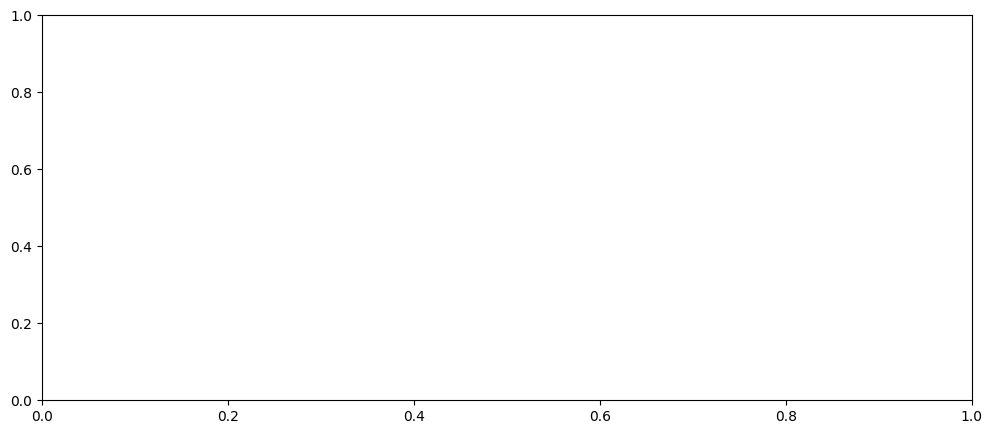

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================================
# TRAINING VISUALIZATION & METRICS
# ============================================================================

print("\n" + "="*80)
print("TRAINING METRICS & VISUALIZATION")
print("="*80 + "\n")

# 1. LOSS CURVE
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(losses)+1), losses, 'b-o', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (Poisson-Gaussian NLL)', fontsize=12)
ax.set_title('Training Loss per Epoch', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(LOG_DIR / "01_loss_curve.png", dpi=150, bbox_inches='tight')
plt.show()

# Print loss statistics
loss_stats = {
    'Epoch': list(range(1, len(losses)+1)),
    'Loss': [f"{l:.4f}" for l in losses],
}
loss_df = pd.DataFrame(loss_stats)
print("📊 LOSS PER EPOCH:")
print(loss_df.to_string(index=False))
print(f"\nLoss Statistics:")
print(f"  Initial loss:  {losses[0]:.4f}")
print(f"  Final loss:    {losses[-1]:.4f}")
print(f"  Min loss:      {min(losses):.4f} (epoch {losses.index(min(losses))+1})")
print(f"  Max loss:      {max(losses):.4f} (epoch {losses.index(max(losses))+1})")
print(f"  Mean loss:     {np.mean(losses):.4f}")
print(f"  Std loss:      {np.std(losses):.4f}")
print(f"  Improvement:   {(losses[0] - losses[-1]):.4f} ({((losses[0] - losses[-1])/losses[0]*100):.1f}%)\n")

# 2. VALIDATION SCORES (if validation was run)
if len(losses) >= 5 and (5 % 10 == 0 or 5 == EPOCHS):
    print("✅ Validation completed at epoch 5")
    print(f"  F1 (content):    {val_results['F1']:.2f} dB")
    print(f"  F2 (noise level): {val_results['F2']:.2f} dB")
    print(f"  F3 (noise level): {val_results['F3']:.2f} dB")
    print(f"  Combined score:   {combined_score:.2f} dB")
    print(f"  vs. Baseline F1:  {val_results['F1'] - LOCKED_DECISIONS['baseline_F1']:.2f} dB improvement")
    print(f"  vs. Baseline F2:  {val_results['F2'] - LOCKED_DECISIONS['baseline_F2']:.2f} dB improvement")
    print(f"  vs. Baseline F3:  {val_results['F3'] - LOCKED_DECISIONS['baseline_F3']:.2f} dB improvement\n")
else:
    print("⏳ Validation will run at epoch 5\n")

# 3. TRAINING STATISTICS TABLE
print("📈 TRAINING SUMMARY:")
summary_data = {
    'Metric': [
        'Total Epochs',
        'Batches per Epoch',
        'Total Batches',
        'Batch Size',
        'Total Patches',
        'Learning Rate',
        'Loss Function',
        'Device',
        'Time Elapsed',
    ],
    'Value': [
        len(losses),
        len(loader),
        len(losses) * len(loader),
        BATCH_SIZE,
        len(dataset),
        f"{LR:.0e}",
        'Poisson-Gaussian NLL',
        str(device),
        str(elapsed),
    ]
}
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False, header=False))
print()

# 4. EARLY STOPPING INFO
if 'early_stopping' in locals() and hasattr(early_stopping, 'best_score'):
    print(f"🛑 EARLY STOPPING:")
    print(f"  Best validation score: {early_stopping.best_score:.4f}")
    print(f"  Best epoch: {early_stopping.best_epoch}")
    print(f"  Patience: {early_stopping.patience}")
    print(f"  Counter: {early_stopping.counter}/{early_stopping.patience}\n")

print("="*80)

##  EVALUATION: stSNR on Validation Stacks (F1, F2, F3)

In [ ]:
import time
from evaluate import denoise_stack, spatio_temporal_snr

# ============================================================================
# EVALUATION: stSNR on Validation Stacks (F1, F2, F3)
# ============================================================================

print("\n" + "="*80)
print("EVALUATION: VALIDATION STACKS")
print("="*80 + "\n")

# Load model for evaluation
model.eval()

# Load clean reference
clean_path = DATA_DIR / "val" / "F0.tif"
print(f"Loading clean reference: {clean_path}")
clean = np.asarray(load_stack(clean_path), dtype=np.float32)

# Evaluate on validation stacks
val_stacks = ['F1', 'F2', 'F3']
eval_results = {}
eval_timings = {}

print(f"\n{'='*80}")
print("EVALUATION RESULTS")
print(f"{'='*80}\n")

eval_start_time = time.time()

for stack_name in val_stacks:
    stack_path = DATA_DIR / "val" / f"{stack_name}.tif"
    print(f"Evaluating {stack_name}...")
    
    noisy = np.asarray(load_stack(stack_path), dtype=np.float32)
    
    # Denoise with timing
    print(f"  Denoising...")
    denoise_start = time.time()
    denoised = denoise_stack(model, noisy, device, patch_size=PATCH_SIZE[0])
    denoise_time = time.time() - denoise_start
    
    # Compute stSNR
    print(f"  Computing stSNR...")
    metrics = spatio_temporal_snr(clean, denoised)
    eval_results[stack_name] = metrics['stSNR']
    eval_timings[stack_name] = denoise_time
    
    print(f"  stSNR:      {metrics['stSNR']:.2f} dB")
    print(f"  sSNR:       {metrics['sSNR']:.2f} dB")
    print(f"  tSNR:       {metrics['tSNR']:.2f} dB")
    print(f"  Time:       {denoise_time:.1f} sec\n")

total_eval_time = time.time() - eval_start_time

# Summary
print("="*80)
print("EVALUATION SUMMARY")
print("="*80)
print(f"F1 (content gen):     {eval_results['F1']:.2f} dB  ({eval_timings['F1']:.1f}s)")
print(f"F2 (noise level gen): {eval_results['F2']:.2f} dB  ({eval_timings['F2']:.1f}s)")
print(f"F3 (noise level gen): {eval_results['F3']:.2f} dB  ({eval_timings['F3']:.1f}s)")
print(f"\nAverage (F1+F2+F3):   {np.mean([eval_results[k] for k in val_stacks]):.2f} dB")
print(f"Noise gen (F2+F3):    {np.mean([eval_results[k] for k in ['F2', 'F3']]):.2f} dB")

print("\n" + "="*80)
print("TIMING")
print("="*80)
print(f"Total evaluation time: {total_eval_time:.1f} sec ({total_eval_time/60:.1f} min)")
print(f"Average per stack:     {total_eval_time/3:.1f} sec")
if total_eval_time > 3600:
    print(f"⚠ WARNING: Exceeds 60-min submission limit! Consider optimization.")
else:
    remaining = 3600 - total_eval_time
    print(f"✓ Well within 60-min limit ({remaining/60:.1f} min buffer)")

# Leaderboard comparison
print("\n" + "="*80)
print("LEADERBOARD COMPARISON")
print("="*80)
print(f"Content Gen (F1):     {eval_results['F1']:.2f} dB (target: 22.14 dB, diff: {eval_results['F1'] - 22.14:+.2f} dB)")
print(f"Noise Gen (F2+F3):    {np.mean([eval_results['F2'], eval_results['F3']]):.2f} dB (target: 16.75 dB, diff: {np.mean([eval_results['F2'], eval_results['F3']]) - 16.75:+.2f} dB)")

print("="*80 + "\n")